
===== FINANCIAL SUMMARY =====
Total Income: 539857
Total Expense: -201794
Savings: 338063

Top Category:
category
Food    64544
Name: amount, dtype: int64


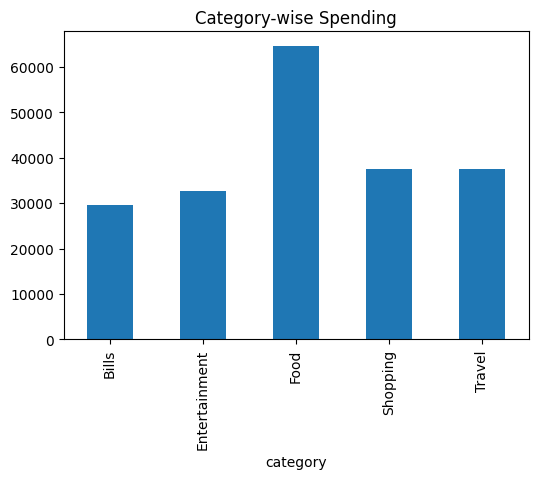

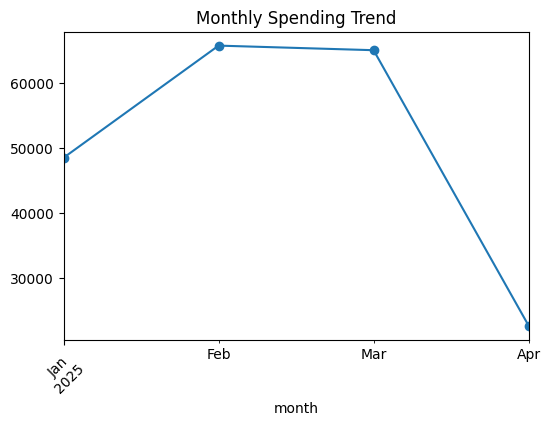

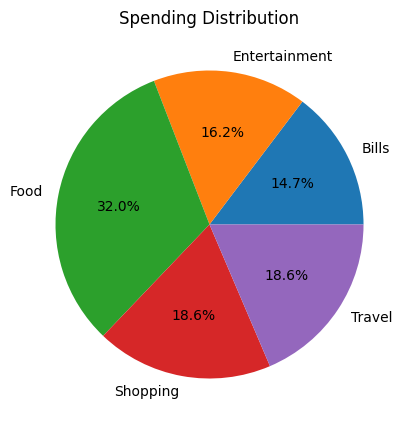


Report generated: expense_report.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ================================
# 💸 PERSONAL EXPENSE TRACKER (ALL-IN-ONE COLAB CELL)
# ================================

!pip install pandas numpy matplotlib seaborn openpyxl -q

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime

# -------------------------------
# 1. CREATE SYNTHETIC DATA
# -------------------------------
categories = ["Food", "Travel", "Shopping", "Bills", "Entertainment", "Income"]

data = []
dates = pd.date_range("2025-01-01", periods=100)

for i in range(100):
    category = random.choice(categories)

    if category == "Income":
        amount = random.randint(20000, 50000)
    else:
        amount = -random.randint(100, 5000)

    data.append([dates[i], category, amount])

df = pd.DataFrame(data, columns=["date", "category", "amount"])

# -------------------------------
# 2. SQLITE DATABASE
# -------------------------------
conn = sqlite3.connect("expenses.db")

df.to_sql("transactions", conn, if_exists="replace", index=False)

df = pd.read_sql("SELECT * FROM transactions", conn)
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

# -------------------------------
# 3. ANALYSIS
# -------------------------------
income = df[df["amount"] > 0]["amount"].sum()
expense = df[df["amount"] < 0]["amount"].sum()
savings = income + expense

category_spend = df[df["amount"] < 0].groupby("category")["amount"].sum().abs()
monthly_spend = df[df["amount"] < 0].groupby("month")["amount"].sum().abs()

# -------------------------------
# 4. OUTPUT PRINT
# -------------------------------
print("\n===== FINANCIAL SUMMARY =====")
print("Total Income:", income)
print("Total Expense:", expense)
print("Savings:", savings)
print("\nTop Category:")
print(category_spend.sort_values(ascending=False).head(1))

# -------------------------------
# 5. VISUALIZATION
# -------------------------------

plt.figure(figsize=(6,4))
category_spend.plot(kind="bar")
plt.title("Category-wise Spending")
plt.show()

plt.figure(figsize=(6,4))
monthly_spend.plot(marker="o")
plt.title("Monthly Spending Trend")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(5,5))
category_spend.plot(kind="pie", autopct="%1.1f%%")
plt.title("Spending Distribution")
plt.ylabel("")
plt.show()

# -------------------------------
# 6. EXPORT REPORT
# -------------------------------
df.to_excel("expense_report.xlsx", index=False)

print("\nReport generated: expense_report.xlsx")

from google.colab import files
files.download("expense_report.xlsx")